# OCRP Checkpoint Walkthrough

This notebook loads a **trained OCRP checkpoint**, pulls a **real test sample**, and walks through the model stage by stage.

The focus is the **upsampler path**:

1. encode LR quaternions into local-iso features
2. apply the LR cosine-masked equivariant conv
3. build the local quaternion and feature banks
4. cluster the quaternion bank into orientation slots
5. build medoid slot contexts
6. do token-conditioned within-slot pooling
7. route the full `4x4` HR patch jointly
8. build per-slot HR patch proposals
9. hard-gather the chosen slot per HR token
10. apply the HR cosine-masked equivariant conv
11. optionally decode to quaternions and render LR/SR/HR IPF maps

Most cells stay in **feature space** so the walkthrough is responsive. The final full-image decode is optional because the decoder is slower than the OCRP feature path.


<!-- code-guide:auto -->
### What This Cell Does

This setup cell finds the repository root, configures temporary cache directories, imports the OCRP model and visualization helpers, and sets print formatting for tensors and arrays.

**Expected:** It should run without printed output. When it finishes, the notebook environment is ready for the remaining cells.


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / 'models').exists():
    candidates = [Path('/data/home/umang/Materials/Reynolds-QSR_4x1'), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'models').exists():
            repo_root = candidate
            break
sys.path.insert(0, str(repo_root))

os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
Path(os.environ['NUMBA_CACHE_DIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from training.config_utils import load_and_prepare_config
from training.quaternion_dataset import QuaternionDataset
from models.SR_ocrp import (
    IsoEmbeddingSROCRP,
    ClusterSlotBuilder,
    _build_local_patch_bank,
    _normalize_quaternions,
)
from utils.symmetry_utils import resolve_symmetry
from visualization.ipf_render import render_ipf_rgb
from visualization.visualize_sr_results import render_sr_hr_lr_side_by_side

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)


## Notebook Anchor

This notebook is anchored to the OCRP experiment directory:

- experiment: `experiments/IN718/iso_embedding_ocrp_01`
- checkpoint: `checkpoints/best_model.pt`
- split: `Test`
- sample: configurable with `SAMPLE_IDX`

The model is instantiated directly from the OCRP config so the walkthrough matches the trained run as closely as possible.


<!-- code-guide:auto -->
### What This Cell Does

This cell defines the experiment paths, runtime options, and helper utilities used throughout the walkthrough, including quaternion reshaping, checkpoint loading, and OCRP probing helpers.

**Expected:** It should also run quietly. The main result is that all reusable functions and constants are available for the later analysis cells.


In [2]:
EXP_DIR = repo_root / 'experiments' / 'IN718' / 'iso_embedding_ocrp_01'
CONFIG_NAME = 'config_new.json'
CHECKPOINT_NAME = 'best_model.pt'
SPLIT = 'Test'
SAMPLE_IDX = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def flatten_quat_image(q: torch.Tensor):
    if q.dim() != 3:
        raise ValueError(f'Expected rank-3 quaternion image, got {tuple(q.shape)}')
    if q.shape[0] == 4:
        h, w = int(q.shape[1]), int(q.shape[2])
        return q.permute(1, 2, 0).reshape(h * w, 4), (h, w)
    if q.shape[-1] == 4:
        h, w = int(q.shape[0]), int(q.shape[1])
        return q.reshape(h * w, 4), (h, w)
    raise ValueError(f'Quaternion axis must be dim=0 or dim=-1 with size 4, got {tuple(q.shape)}')

def to_hwc_quat(q_like, hw=None):
    if isinstance(q_like, torch.Tensor):
        q_like = q_like.detach().cpu()
    arr = np.asarray(q_like)
    if arr.ndim == 2:
        if hw is None:
            raise ValueError('Need hw for flat quaternion arrays')
        return arr.reshape(int(hw[0]), int(hw[1]), 4)
    if arr.ndim == 3 and arr.shape[0] == 4:
        return np.transpose(arr, (1, 2, 0))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        return arr
    raise ValueError(f'Unsupported quaternion array shape: {arr.shape}')

def patch_ipf_rgb(q_patch, sym_class, ref_dir='X'):
    q_patch = np.asarray(q_patch, dtype=np.float32)
    if q_patch.ndim != 3 or q_patch.shape[-1] != 4:
        raise ValueError(f'Expected patch quaternion array (H,W,4), got {q_patch.shape}')
    h, w = q_patch.shape[:2]
    q_line = q_patch.reshape(1, h * w, 4)
    rgb_line = render_ipf_rgb(q_line, sym_class, ref_dir=ref_dir)
    return np.asarray(rgb_line).reshape(h, w, 3)

def build_ocrp_from_cfg(cfg, device):
    model = IsoEmbeddingSROCRP(
        crystal=cfg.crystal,
        d6_convention=cfg.d6_convention,
        device=device,
        feature_irreps=cfg.feature_irreps,
        use_lr_conv1=cfg.use_lr_conv1,
        lr_conv1_kernel_size=cfg.lr_conv1_kernel_size,
        use_residual_lr1=cfg.use_residual_lr1,
        conv_feature_mask_cosine_threshold=cfg.conv_feature_mask_cosine_threshold,
        conv_feature_mask_soft=cfg.conv_feature_mask_soft,
        conv_feature_mask_temperature=cfg.conv_feature_mask_temperature,
        upsample_factor=cfg.upsample_factor,
        window_size=cfg.window_size,
        kmax_slots=cfg.kmax_slots,
        cluster_threshold_deg=cfg.cluster_threshold_deg,
        cluster_connectivity=cfg.cluster_connectivity,
        phase_dim=cfg.phase_dim,
        ocrp_router_hidden_dim=cfg.ocrp_router_hidden_dim,
        ocrp_router_conv_hidden_dim=cfg.ocrp_router_conv_hidden_dim,
        ocrp_proposal_hidden_dim=cfg.ocrp_proposal_hidden_dim,
        ocrp_straight_through=cfg.ocrp_straight_through,
        use_hr_conv1=cfg.use_hr_conv1,
        hr_conv1_kernel_size=cfg.hr_conv1_kernel_size,
        use_residual_hr1=cfg.use_residual_hr1,
        decoder_cubochoric_resolution=cfg.decoder_cubochoric_resolution,
        decoder_num_starts=cfg.decoder_num_starts,
        decoder_steps=cfg.decoder_steps,
        decoder_lr=cfg.decoder_lr,
        decoder_method=getattr(cfg, 'decoder_method', 'cubochoric'),
        decoder_max_table_rows=cfg.decoder_max_table_rows,
        decoder_table_cache_dir=cfg.decoder_table_cache_dir,
        decoder_eager_init=cfg.decoder_eager_init,
    )
    return model.to(device)

def load_checkpoint_weights(model, checkpoint_path, device):
    try:
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        ckpt = torch.load(checkpoint_path, map_location=device)
    except Exception:
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state_dict = ckpt.get('model_state_dict', ckpt)
    model.load_state_dict(state_dict, strict=True)
    return model.to(device)

def tensor_shape_markdown(stage_map):
    lines = ['| stage | shape | dtype |', '|---|---|---|']
    for name, tensor in stage_map.items():
        if tensor is None:
            lines.append(f'| `{name}` | `None` | `-` |')
        else:
            lines.append(f'| `{name}` | `{tuple(tensor.shape)}` | `{tensor.dtype}` |')
    return '\n'.join(lines)

SLOT_TYPE_NAMES = ['parent', 'alt1', 'alt2', 'null']

def slot_meta_markdown(slot_meta_row, medoid_row, cluster_label_row):
    meta = slot_meta_row.detach().cpu().numpy()
    medoid = medoid_row.detach().cpu().numpy()
    cluster_labels = cluster_label_row.detach().cpu().numpy()
    lines = [
        '| slot | valid | type | mass | centroid_y | centroid_x | spatial_disp | medoid_bank_idx | cluster_label |',
        '|---|---:|---|---:|---:|---:|---:|---:|---:|',
    ]
    for slot_idx in range(meta.shape[0]):
        slot_type = int(np.argmax(meta[slot_idx, ClusterSlotBuilder.META_SLOT_TYPE_START:ClusterSlotBuilder.META_SLOT_TYPE_START + ClusterSlotBuilder.SLOT_TYPE_DIM]))
        lines.append(
            '| {} | {:.0f} | {} | {:.3f} | {:.3f} | {:.3f} | {:.3f} | {} | {} |'.format(
                slot_idx + 1,
                meta[slot_idx, ClusterSlotBuilder.META_VALID],
                SLOT_TYPE_NAMES[slot_type],
                meta[slot_idx, ClusterSlotBuilder.META_MASS],
                meta[slot_idx, ClusterSlotBuilder.META_CENTROID_Y],
                meta[slot_idx, ClusterSlotBuilder.META_CENTROID_X],
                meta[slot_idx, ClusterSlotBuilder.META_SPATIAL_DISP],
                int(medoid[slot_idx]),
                int(cluster_labels[slot_idx]),
            )
        )
    return '\n'.join(lines)

def window_index_to_xy(win_idx, lr_shape):
    h, w = int(lr_shape[0]), int(lr_shape[1])
    return divmod(int(win_idx), w)

def choose_probe_window(aux):
    owner = aux['owner_idx'][0].detach().cpu()
    slot_valid = aux['slot_valid'][0].detach().cpu().sum(dim=-1)
    multi_owner = torch.tensor([torch.unique(owner[i]).numel() > 1 for i in range(owner.shape[0])])
    candidates = torch.nonzero((slot_valid >= 2) & multi_owner, as_tuple=False)
    if len(candidates) > 0:
        return int(candidates[0, 0].item())
    fallback = torch.nonzero(slot_valid >= 2, as_tuple=False)
    if len(fallback) > 0:
        return int(fallback[0, 0].item())
    return 0



<!-- code-guide:auto -->
### What This Cell Does

This cell loads the config, dataset sample, and trained checkpoint, then runs the encoder and OCRP feature pipeline once so we can inspect the saved intermediate tensors in `aux`.

**Expected:** It should print the experiment path, checkpoint path, selected split/sample, active device, and the LR and HR shapes involved in the forward pass.


In [3]:
cfg = load_and_prepare_config(EXP_DIR / CONFIG_NAME, save_path=None)
sym_class = resolve_symmetry(getattr(cfg, 'symmetry_group', 'Oh'))

dataset = QuaternionDataset(
    cfg.dataset_root,
    split=SPLIT,
    preload=False,
    preload_torch=False,
)
lr_img, hr_img = dataset[SAMPLE_IDX]
lr_flat, lr_shape = flatten_quat_image(lr_img)
hr_flat, hr_shape_gt = flatten_quat_image(hr_img)

model = build_ocrp_from_cfg(cfg, DEVICE)
model = load_checkpoint_weights(model, EXP_DIR / 'checkpoints' / CHECKPOINT_NAME, DEVICE)
model.eval()

with torch.no_grad():
    lr_in = _normalize_quaternions(lr_flat.unsqueeze(0).to(DEVICE))
    feat_lr = model.encode(lr_in)
    feat_hr_post, hr_shape_model, aux = model._forward_sr_features(
        lr_quats=lr_in,
        feat_lr=feat_lr,
        lr_shape=lr_shape,
        return_aux=True,
    )

print(f'Experiment: {EXP_DIR}')
print(f'Checkpoint: {EXP_DIR / "checkpoints" / CHECKPOINT_NAME}')
print(f'Split/sample: {SPLIT}/{SAMPLE_IDX}')
print(f'Device: {DEVICE}')
print(f'LR shape: {lr_shape}, HR target shape: {hr_shape_gt}, HR model shape: {hr_shape_model}')


Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 8 (default: 4)
  - symmetry_group: Oh (default: O)
  - use_amp: True (default: False)
  - decoder_steps: 20 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - viz_every: 1 (default: 5)
  - num_workers: 8 (default: 0)
  - persistent_workers: True (default: False)
  - prefetch_factor: 4 (default: 2)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - cudnn_benchmark: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_ocrp (default: iso_embedding_sr_attn)
Using existing symmetry files for Oh
Experiment: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_ocrp_01
Checkpoint: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_ocrp_01/checkpoints/best_model.pt
Split/sample:

<!-- code-guide:auto -->
### What This Cell Does

This cell collects the most important OCRP intermediate tensors into one dictionary and renders a compact summary table of their shapes and dtypes.

**Expected:** It should display a markdown table showing each stage name, tensor shape, and dtype so you can verify the feature flow at a glance.


In [4]:
stage_map = {
    'lr_in': lr_in,
    'feat_lr': feat_lr,
    'feat_lr_pre_ocrp': aux['feat_lr_pre_ocrp'],
    'bank_q': aux['bank_q'],
    'bank_f': aux['bank_f'],
    'cluster_ids': aux['cluster_ids'],
    'slot_mask': aux['slot_mask'],
    'slot_valid': aux['slot_valid'],
    'slot_meta': aux['slot_meta'],
    'slot_ctx': aux['slot_ctx'],
    'slot_pooled_ctx': aux['slot_pooled_ctx'],
    'slot_pool_alpha': aux['slot_pool_alpha'],
    'router_logits': aux['router_logits'],
    'owner_idx': aux['owner_idx'],
    'patch_prop': aux['patch_prop'],
    'patch_out': aux['patch_out'],
    'feat_hr_raw_ocrp': aux['feat_hr_raw_ocrp'],
    'feat_hr_post_hr_conv': aux['feat_hr_post_hr_conv'],
}
display(Markdown(tensor_shape_markdown(stage_map)))


| stage | shape | dtype |
|---|---|---|
| `lr_in` | `(1, 1024, 4)` | `torch.float32` |
| `feat_lr` | `(1, 1024, 14)` | `torch.float32` |
| `feat_lr_pre_ocrp` | `(1, 1024, 14)` | `torch.float32` |
| `bank_q` | `(1, 1024, 121, 4)` | `torch.float32` |
| `bank_f` | `(1, 1024, 121, 14)` | `torch.float32` |
| `cluster_ids` | `(1, 1024, 121)` | `torch.int64` |
| `slot_mask` | `(1, 1024, 4, 121)` | `torch.bool` |
| `slot_valid` | `(1, 1024, 4)` | `torch.float32` |
| `slot_meta` | `(1, 1024, 4, 9)` | `torch.float32` |
| `slot_ctx` | `(1, 1024, 4, 14)` | `torch.float32` |
| `slot_pooled_ctx` | `(1, 1024, 4, 16, 14)` | `torch.float32` |
| `slot_pool_alpha` | `(1, 1024, 4, 16, 121)` | `torch.float32` |
| `router_logits` | `(1, 1024, 16, 4)` | `torch.float32` |
| `owner_idx` | `(1, 1024, 16)` | `torch.int64` |
| `patch_prop` | `(1, 1024, 4, 16, 14)` | `torch.float32` |
| `patch_out` | `(1, 1024, 16, 14)` | `torch.float32` |
| `feat_hr_raw_ocrp` | `(1, 16384, 14)` | `torch.float32` |
| `feat_hr_post_hr_conv` | `(1, 16384, 14)` | `torch.float32` |

## Manual OCRP Step-Through

The next cell reproduces the OCRP upsampler explicitly from its submodules and checks that the manual reconstruction matches the tensors cached in `aux`.


<!-- code-guide:auto -->
### What This Cell Does

This cell reconstructs the OCRP path step by step by hand, from local patch banks through routing and patch assembly, and then compares each manually built tensor with the stored forward-pass outputs.

**Expected:** It should return a dictionary of maximum absolute differences. The values are expected to be very small, ideally at or near numerical precision, which confirms the walkthrough matches the model internals.


In [5]:
with torch.no_grad():
    feat_pre_manual = model.conv_lr1(feat_lr, lr_shape) if model.use_lr_conv1 else feat_lr

    bank_q = _build_local_patch_bank(lr_in, img_shape=lr_shape, window_size=model.ocrp.window_size)
    bank_f = _build_local_patch_bank(feat_pre_manual, img_shape=lr_shape, window_size=model.ocrp.window_size)

    cluster_ids = model.ocrp.clusterer(bank_q)
    slot_info = model.ocrp.slot_builder(cluster_ids)
    slot_ctx, medoid_bank_idx = model.ocrp.context_builder(
        bank_q=bank_q,
        bank_f=bank_f,
        slot_mask=slot_info['slot_mask'],
    )
    phase_grid = model.ocrp._phase_grid(device=feat_lr.device, dtype=feat_lr.dtype)
    slot_pooled_ctx, slot_pool_alpha = model.ocrp.slot_pool(
        slot_anchor_ctx=slot_ctx,
        slot_meta=slot_info['slot_meta'],
        bank_f=bank_f,
        slot_mask=slot_info['slot_mask'],
        phase_grid=phase_grid,
        return_alpha=True,
    )
    router_logits = model.ocrp.router(
        slot_ctx=slot_ctx,
        slot_meta=slot_info['slot_meta'],
        phase_grid=phase_grid,
        weak_parent_prior=feat_pre_manual,
    )
    owner_idx_manual, owner_onehot_manual = model.ocrp._hard_owner_from_logits(
        router_logits,
        straight_through=False,
    )
    patch_prop = model.ocrp.proposal_head(
        slot_ctx=slot_pooled_ctx,
        slot_meta=slot_info['slot_meta'],
        phase_grid=phase_grid,
        weak_parent_prior=feat_pre_manual,
        slot_anchor_ctx=slot_ctx,
    )
    owner_mask = owner_onehot_manual.permute(0, 1, 3, 2).unsqueeze(-1)
    patch_out = (owner_mask * patch_prop).sum(dim=2)
    feat_hr_raw_manual = model.ocrp._assemble_patch_tokens(patch_out, lr_shape=lr_shape)
    feat_hr_post_manual = model.conv_hr1(feat_hr_raw_manual, hr_shape_model) if model.use_hr_conv1 else feat_hr_raw_manual

max_diffs = {
    'feat_lr_pre_ocrp': float((feat_pre_manual - aux['feat_lr_pre_ocrp']).abs().max().item()),
    'bank_q': float((bank_q - aux['bank_q']).abs().max().item()),
    'cluster_ids': float((cluster_ids - aux['cluster_ids']).abs().max().item()),
    'slot_ctx': float((slot_ctx - aux['slot_ctx']).abs().max().item()),
    'slot_pooled_ctx': float((slot_pooled_ctx - aux['slot_pooled_ctx']).abs().max().item()),
    'router_logits': float((router_logits - aux['router_logits']).abs().max().item()),
    'patch_prop': float((patch_prop - aux['patch_prop']).abs().max().item()),
    'patch_out': float((patch_out - aux['patch_out']).abs().max().item()),
    'feat_hr_raw_ocrp': float((feat_hr_raw_manual - aux['feat_hr_raw_ocrp']).abs().max().item()),
    'feat_hr_post_hr_conv': float((feat_hr_post_manual - aux['feat_hr_post_hr_conv']).abs().max().item()),
}
max_diffs


{'feat_lr_pre_ocrp': 0.0,
 'bank_q': 0.0,
 'cluster_ids': 0.0,
 'slot_ctx': 0.0,
 'slot_pooled_ctx': 0.0,
 'router_logits': 0.0,
 'patch_prop': 0.0,
 'patch_out': 0.0,
 'feat_hr_raw_ocrp': 0.0,
 'feat_hr_post_hr_conv': 0.0}

<!-- code-guide:auto -->
### What This Cell Does

This cell computes global routing statistics across all windows, including how many valid slots appear, how often multiple slots are used inside one HR patch, and how confident the router is.

**Expected:** It should print histograms and a top1-top2 margin summary that help you judge how selective and decisive the OCRP routing behavior is on this sample.


In [6]:
slot_count = aux['slot_valid'][0].sum(dim=-1).detach().cpu()
owner = aux['owner_idx'][0].detach().cpu()
probs = torch.softmax(aux['router_logits'][0].detach().cpu(), dim=-1)
top2 = torch.topk(probs, k=2, dim=-1).values
margin = top2[..., 0] - top2[..., 1]

windows_with_multi_owner = int(sum(torch.unique(owner[i]).numel() > 1 for i in range(owner.shape[0])))
slot_hist = torch.bincount(slot_count.to(torch.int64), minlength=int(slot_count.max().item()) + 1)
owner_hist = torch.bincount(owner.reshape(-1), minlength=model.ocrp.kmax_slots)

print('Windows by valid slot count:')
for idx, count in enumerate(slot_hist.tolist()):
    print(f'  {idx} valid slots: {count}')
print(f'Windows whose 4x4 patch uses more than one slot: {windows_with_multi_owner}/{owner.shape[0]}')
print('Owner-slot histogram across all HR tokens:')
for slot_idx, count in enumerate(owner_hist.tolist()):
    print(f'  slot {slot_idx + 1}: {count}')
print(f'Router top1-top2 margin: mean={margin.mean().item():.4f}, median={margin.median().item():.4f}, min={margin.min().item():.4f}')


Windows by valid slot count:
  0 valid slots: 0
  1 valid slots: 121
  2 valid slots: 197
  3 valid slots: 706
Windows whose 4x4 patch uses more than one slot: 181/1024
Owner-slot histogram across all HR tokens:
  slot 1: 15413
  slot 2: 853
  slot 3: 118
  slot 4: 0
Router top1-top2 margin: mean=0.4653, median=0.2343, min=0.0000


<!-- code-guide:auto -->
### What This Cell Does

This cell defines a reusable visualization helper for a single LR window. The helper plots cluster assignments, selected owners, routing margins, pooling maps, slot metadata, and decoded slot proposals.

**Expected:** It is a definition-only cell, so it should not display anything yet. After it runs, `show_window_probe(...)` is available for targeted inspection.


In [7]:
def show_window_probe(win_idx, ref_dir='X'):
    win_y, win_x = window_index_to_xy(win_idx, lr_shape)
    window = model.ocrp.window_size
    r = model.ocrp.upsample_factor

    cluster_map = aux['cluster_ids'][0, win_idx].detach().cpu().reshape(window, window).numpy()
    owner_patch = aux['owner_idx'][0, win_idx].detach().cpu().reshape(r, r).numpy()
    probs_patch = torch.softmax(aux['router_logits'][0, win_idx].detach().cpu(), dim=-1)
    topk_patch = torch.topk(probs_patch, k=2, dim=-1).values
    margin_patch = (topk_patch[:, 0] - topk_patch[:, 1]).reshape(r, r).numpy()

    slot_valid = aux['slot_valid'][0, win_idx].detach().cpu().numpy()
    valid_slots = [i for i, v in enumerate(slot_valid.tolist()) if v > 0.5]
    ncols = max(3, len(valid_slots))
    fig, axes = plt.subplots(2, ncols, figsize=(4.0 * ncols, 7.0))
    axes = np.asarray(axes)

    im0 = axes[0, 0].imshow(cluster_map, cmap='tab20', interpolation='nearest')
    axes[0, 0].set_title(f'cluster_ids | LR window ({win_y}, {win_x})')
    axes[0, 0].scatter([window // 2], [window // 2], c='white', marker='s', s=60, edgecolors='black')
    axes[0, 0].axis('off')
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

    im1 = axes[0, 1].imshow(owner_patch, cmap='tab10', vmin=0, vmax=max(0, model.ocrp.kmax_slots - 1), interpolation='nearest')
    axes[0, 1].set_title('owner_idx over 4x4 HR patch')
    axes[0, 1].axis('off')
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    im2 = axes[0, 2].imshow(margin_patch, cmap='magma', interpolation='nearest')
    axes[0, 2].set_title('router top1-top2 margin')
    axes[0, 2].axis('off')
    fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

    for j in range(3, ncols):
        axes[0, j].axis('off')

    for j, slot_idx in enumerate(valid_slots):
        alpha_mean = aux['slot_pool_alpha'][0, win_idx, slot_idx].detach().cpu().mean(dim=0).reshape(window, window).numpy()
        axes[1, j].imshow(alpha_mean, cmap='viridis', interpolation='nearest')
        my, mx = divmod(int(aux['medoid_bank_idx'][0, win_idx, slot_idx].item()), window)
        axes[1, j].scatter([mx], [my], c='red', marker='x', s=70)
        axes[1, j].set_title(f'slot {slot_idx + 1} mean pool alpha')
        axes[1, j].axis('off')
    for j in range(len(valid_slots), ncols):
        axes[1, j].axis('off')

    plt.tight_layout()
    plt.show()

    display(Markdown(slot_meta_markdown(
        slot_info['slot_meta'][0, win_idx],
        medoid_bank_idx[0, win_idx],
        slot_info['slot_cluster_label'][0, win_idx],
    )))

    decoded_patches = []
    with torch.enable_grad():
        final_patch_q = model.decode(aux['patch_out'][0, win_idx].unsqueeze(0)).squeeze(0).detach().cpu()
        decoded_patches.append(('selected patch', to_hwc_quat(final_patch_q, (r, r))))
        for slot_idx in valid_slots:
            slot_patch_q = model.decode(aux['patch_prop'][0, win_idx, slot_idx].unsqueeze(0)).squeeze(0).detach().cpu()
            decoded_patches.append((f'slot {slot_idx + 1} proposal', to_hwc_quat(slot_patch_q, (r, r))))

    fig, axes = plt.subplots(1, len(decoded_patches), figsize=(3.5 * len(decoded_patches), 3.5))
    if len(decoded_patches) == 1:
        axes = [axes]
    for ax, (title, q_patch) in zip(axes, decoded_patches):
        rgb = patch_ipf_rgb(q_patch, sym_class, ref_dir=ref_dir)
        ax.imshow(rgb, interpolation='nearest')
        ax.set_title(f'{title} | IPF-{ref_dir}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


<!-- code-guide:auto -->
### What This Cell Does

This cell picks a representative probe window and calls the visualization helper so you can inspect one local OCRP decision in detail.

**Expected:** It should print the chosen window index and LR coordinates, then render diagnostic plots plus a markdown table describing the valid slots for that window.


Probe window index: 3 -> LR location (0, 3)


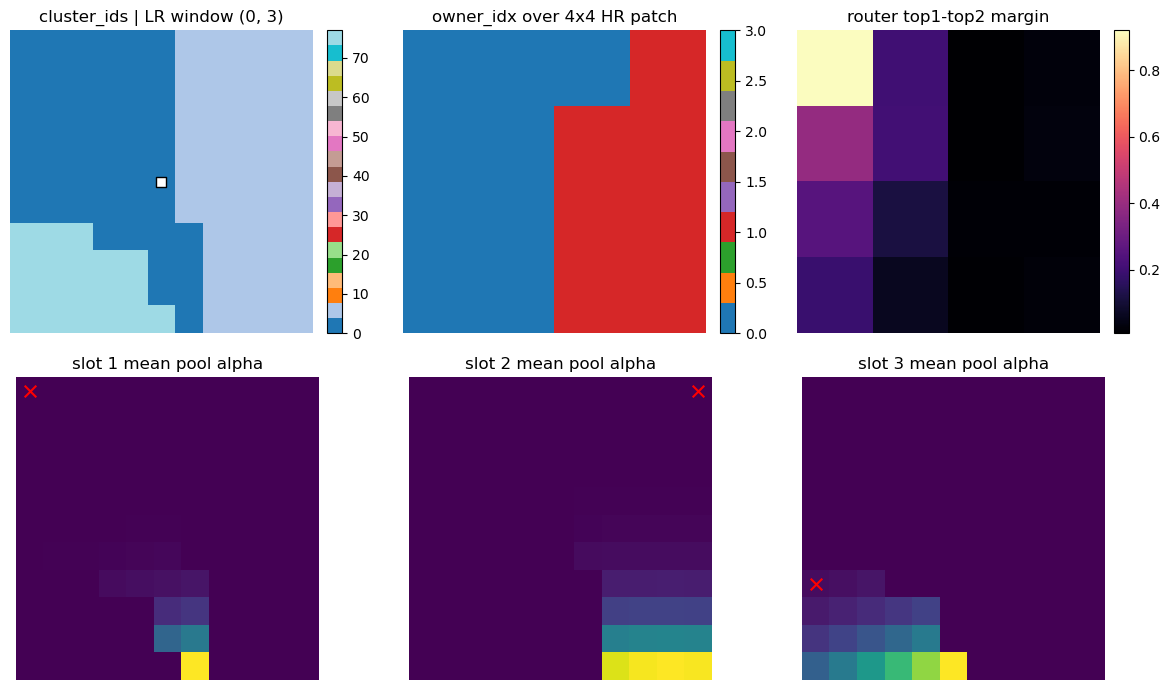

| slot | valid | type | mass | centroid_y | centroid_x | spatial_disp | medoid_bank_idx | cluster_label |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| 1 | 1 | parent | 0.421 | -0.224 | -0.408 | 0.428 | 0 | 0 |
| 2 | 1 | alt1 | 0.421 | -0.055 | 0.631 | 0.459 | 10 | 6 |
| 3 | 1 | alt2 | 0.157 | 0.747 | -0.600 | 0.138 | 77 | 77 |
| 4 | 0 | null | 0.000 | 0.000 | 0.000 | 0.000 | -1 | -1 |

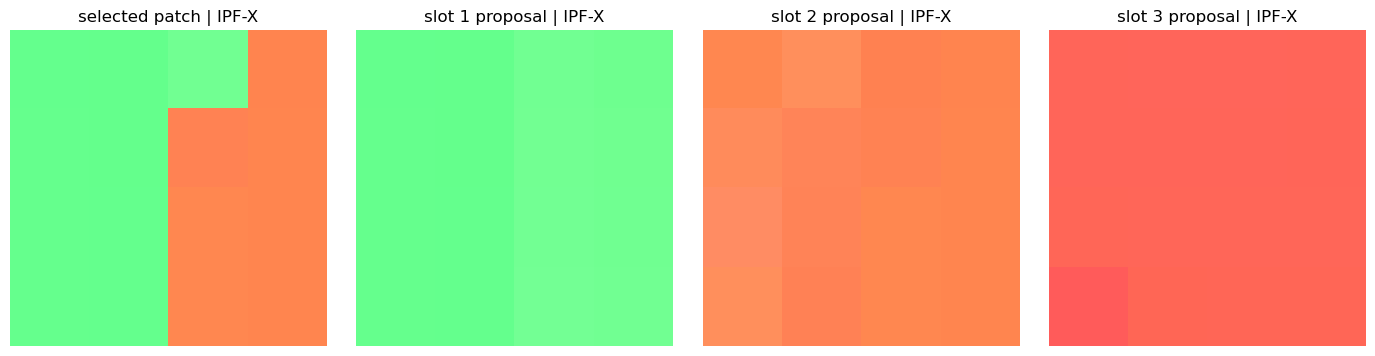

In [8]:
PROBE_WIN_IDX = choose_probe_window(aux)
probe_y, probe_x = window_index_to_xy(PROBE_WIN_IDX, lr_shape)
print(f'Probe window index: {PROBE_WIN_IDX} -> LR location ({probe_y}, {probe_x})')
show_window_probe(PROBE_WIN_IDX, ref_dir='X')


## Optional Full Decode

The OCRP feature walk-through above is the main diagnostic path. If you want the familiar LR/SR/HR IPF comparison for the full image, turn on the flag in the next cell.

This is slower because `model.decode(...)` runs the local-iso decoder over the full `128x128` HR feature map.


<!-- code-guide:auto -->
### What This Cell Does

This final cell optionally decodes the full super-resolved feature map back to quaternions and renders the LR, SR, and HR comparison view for the selected sample.

**Expected:** If `RUN_FULL_IMAGE_DECODE` is `True`, it should display the side-by-side orientation figure. If it is `False`, it will print a reminder telling you to enable the decode first.


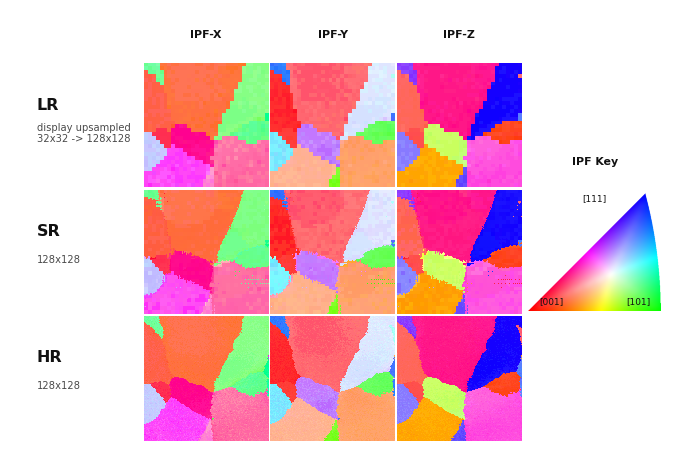

In [9]:
RUN_FULL_IMAGE_DECODE = True

if RUN_FULL_IMAGE_DECODE:
    with torch.enable_grad():
        sr_q_flat = model.decode(aux['feat_hr_post_hr_conv']).squeeze(0).detach().cpu()
    sr_q = to_hwc_quat(sr_q_flat, hr_shape_model)
    lr_q = to_hwc_quat(lr_img)
    hr_q = to_hwc_quat(hr_img)
    render_sr_hr_lr_side_by_side(
        sr_q_arr=sr_q,
        hr_q_arr=hr_q,
        lr_q_arr=lr_q,
        sym_class=sym_class,
        ref_dir='ALL',
        include_key=True,
        out_png=None,
        overwrite=True,
    )
else:
    print('Set RUN_FULL_IMAGE_DECODE = True and rerun this cell to render the full LR/SR/HR comparison.')
